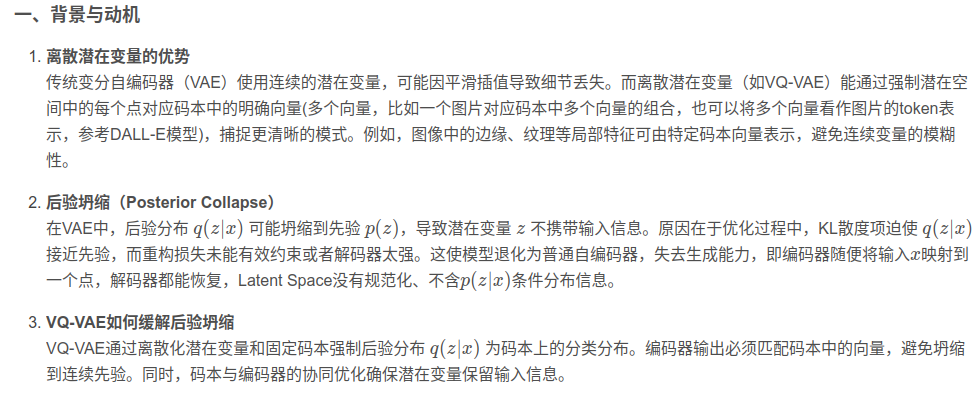

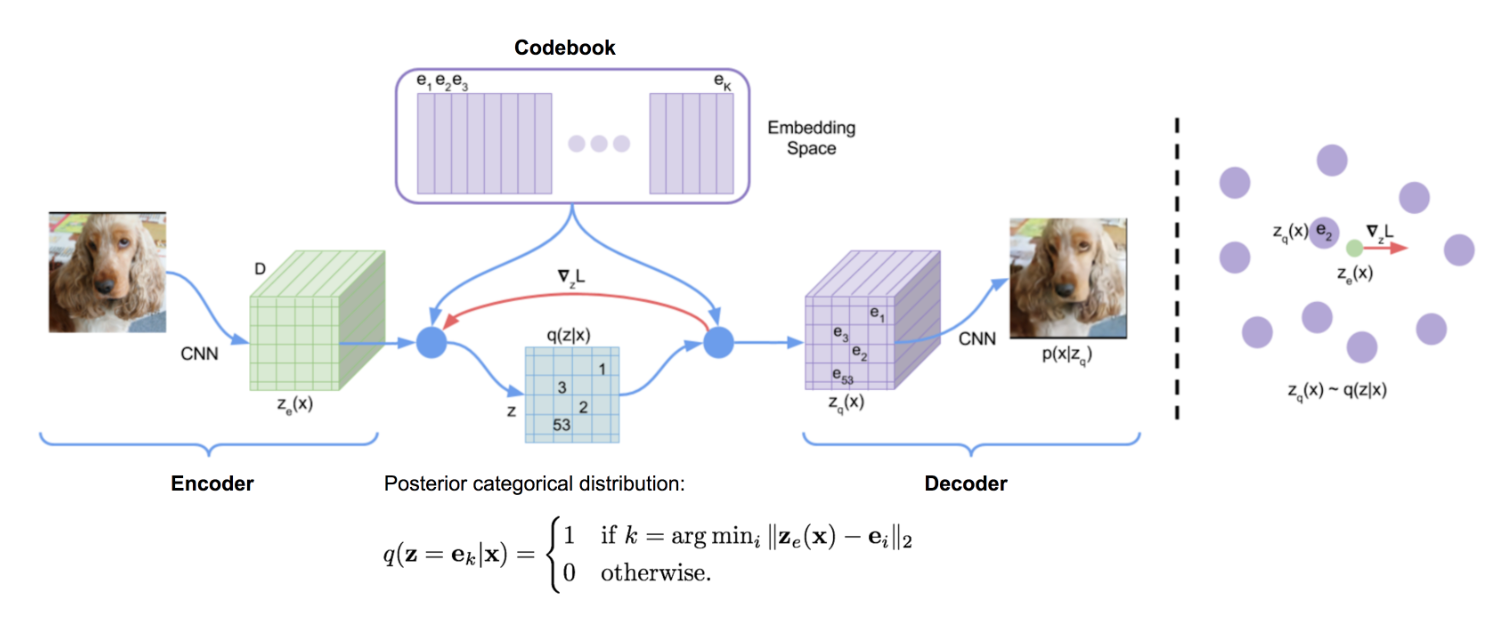

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F

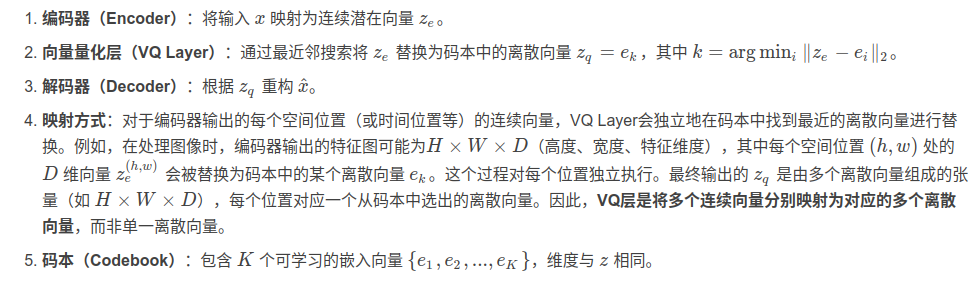

In [3]:
"""
    编码器与解码器（以图像为例）
"""
class Encoder(nn.Module):
    """ 输入图像 [B, C, H, W] → 输出连续潜在变量 [B, D, H', W'] """
    def __init__(self, in_channels=3, latent_dim=64):
        super().__init__()
        self.model = nn.Sequential(
            nn.Conv2d(in_channels, 32, 4, stride=2, padding=1),  # 128x128 → 64x64
            nn.ReLU(),
            nn.Conv2d(32, 64, 4, stride=2, padding=1),          # 64x64 → 32x32
            nn.ReLU(),
            nn.Conv2d(64, latent_dim, 1)                        # 调整通道数
        )

    def forward(self, x):
        return self.model(x)

class Decoder(nn.Module):
    """ 输入量化潜在变量 [B, D, H', W'] → 输出重构图像 [B, C, H, W] """
    def __init__(self, out_channels=3, latent_dim=64):
        super().__init__()
        self.model = nn.Sequential(
            nn.Conv2d(latent_dim, 64, 3, padding=1),
            nn.ReLU(),
            nn.Upsample(scale_factor=2),                        # 32x32 → 64x64
            nn.Conv2d(64, 32, 3, padding=1),
            nn.ReLU(),
            nn.Upsample(scale_factor=2),                        # 64x64 → 128x128
            nn.Conv2d(32, out_channels, 3, padding=1),
            nn.Tanh()  # 输出归一化到 [-1, 1]
        )

    def forward(self, z_q):
        return self.model(z_q)

在这里，codebook就是个矩阵，里面存了 n 条特征向量，用于查询。

最近邻索引的计算公式（欧氏距离平方）：

- 令 z 为输入向量，e 为 codebook 中的某个 embedding：

  $$\|z - e\|^2 = \|z\|^2 + \|e\|^2 - 2 \cdot z \cdot e$$

    其中：
    - z: 输入连续潜变量 (flatten 后的 z_e)
    - e: Codebook 中的 embedding 向量



困惑度（Perplexity）用于衡量 codebook 中各个 embedding 的使用均匀程度。

- 令每个 codebook 索引的使用概率为 $p_i$（即被选中次数的归一化概率）。
- 困惑度定义为：

  $$\text{perplexity} = \exp\left(-\sum_i p_i \log p_i\right)$$

- 当每个 embedding 被均匀使用时，$p_i = 1 / \text{num\_embeddings}$，此时困惑度最大，接近 $\text{num\_embeddings}$。
- 困惑度较低时，说明模型更倾向于只使用少数几个 codebook 向量（codebook 未被充分利用）。

在代码里，我们通过统计 `encoding_indices` 的频率（`torch.histc`）来近似计算 $p_i$，然后用上面的公式得到困惑度。

In [ ]:
"""
    向量量化层（VQ Layer）
"""
class VectorQuantizer(nn.Module):
    def __init__(self, num_embeddings, embedding_dim, commitment_cost=0.25):
        super().__init__()
        self.embedding_dim = embedding_dim
        self.num_embeddings = num_embeddings
        self.commitment_cost = commitment_cost
        
        # 初始化 Codebook
        self.embeddings = nn.Embedding(self.num_embeddings, self.embedding_dim)
        nn.init.uniform_(self.embeddings.weight, -1/self.num_embeddings, 1/self.num_embeddings)

    def _get_nearest_codebook_indices(self, z_e_flat):
        """计算最近邻的 Codebook 索引.
        Args:
            z_e_flat: Tensor, 形状 [BHW, D]

        Returns:
            encoding_indices: Tensor, 形状 [BHW], 最近邻 Codebook 索引
            quantized_flat: Tensor, 形状 [BHW, D], 由索引查询得到的 embedding
        """
        # 计算与 Codebook 的距离 [BHW, K]
        distances = torch.sum(z_e_flat**2, dim=1, keepdim=True) + \
            torch.sum(self.embeddings.weight**2, dim=1) - \
            2 * torch.matmul(z_e_flat, self.embeddings.weight.t())

        # 找到最近邻的 Codebook 索引
        encoding_indices = torch.argmin(distances, dim=1)
        quantized_flat = self.embeddings(encoding_indices)
        return encoding_indices, quantized_flat

    def forward(self, z_e):
        """
        输入: z_e (Tensor) - 编码器输出的连续潜在变量 [B, D, H, W]
        输出: z_q (Tensor) - 量化后的离散潜在变量 [B, D, H, W]
              loss (Tensor) - 量化总损失
              perplexity (Tensor) - Codebook 使用困惑度
        """
        # 调整维度: [B, D, H, W] → [B, H, W, D] → [BHW, D]
        z_e_flat = z_e.permute(0, 2, 3, 1).contiguous()
        z_e_flat = z_e_flat.view(-1, self.embedding_dim)
        
        # 计算最近邻索引和对应的量化向量
        encoding_indices, quantized_flat = self._get_nearest_codebook_indices(z_e_flat)
        
        # 计算损失
        q_loss = F.mse_loss(quantized_flat.detach(), z_e_flat)  # 码本Loss
        e_loss = F.mse_loss(z_e_flat.detach(), quantized_flat)  # Commitment Loss
        loss = q_loss + self.commitment_cost * e_loss
        
        # 直通梯度：z_q = z_e + (z_q - z_e).detach()
        quantized_flat = z_e_flat + (quantized_flat - z_e_flat).detach()
        
        # 恢复原始维度 [B, D, H, W]
        quantized = quantized_flat.view(z_e.shape[0], z_e.shape[2], z_e.shape[3], self.embedding_dim)
        quantized = quantized.permute(0, 3, 1, 2).contiguous()
        
        # 计算困惑度（Codebook 使用均匀性），码书使用频率的熵
        avg_probs = torch.histc(encoding_indices.float(), bins=self.num_embeddings, min=0, max=self.num_embeddings-1)
        perplexity = torch.exp(-torch.sum(avg_probs * torch.log(avg_probs + 1e-10)))
        
        return quantized, loss, perplexity
        

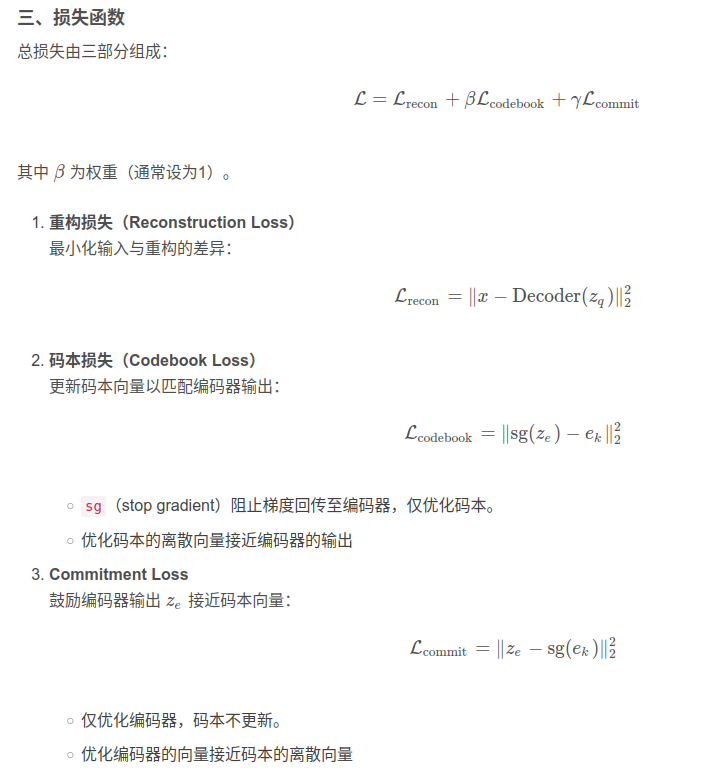

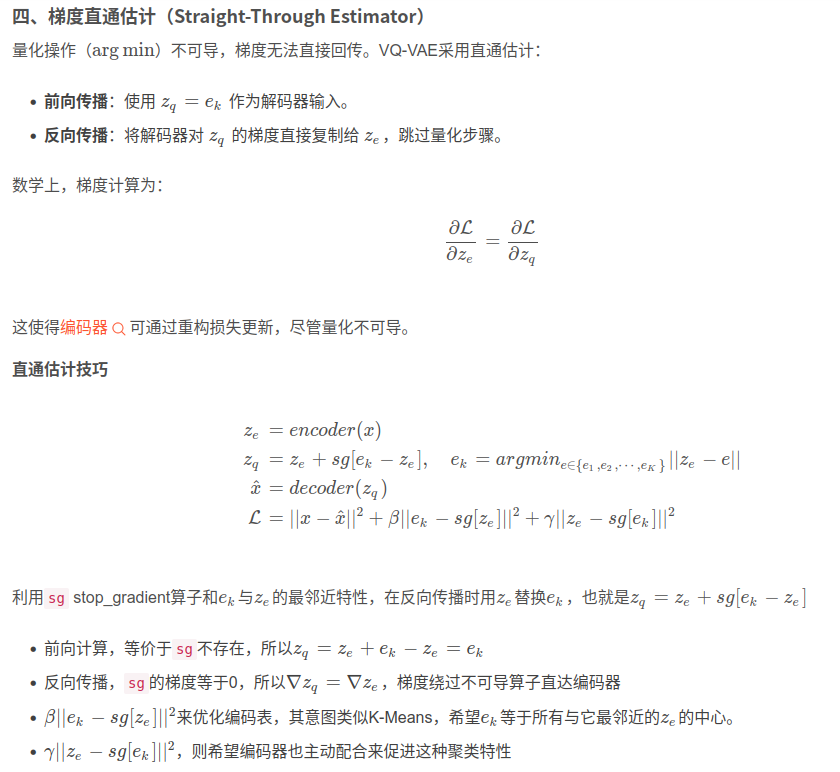

In [4]:
"""
    完整 VQ-VAE 模型
"""
class VQVAE(nn.Module):
    def __init__(self, in_channels=3, latent_dim=64, num_embeddings=512, commitment_cost=0.25):
        super().__init__()
        self.encoder = Encoder(in_channels, latent_dim)
        self.vq_layer = VectorQuantizer(num_embeddings, latent_dim, commitment_cost)
        self.decoder = Decoder(in_channels, latent_dim)

    def forward(self, x):
        # 编码 → 量化 → 解码
        z_e = self.encoder(x)
        z_q, vq_loss, perplexity = self.vq_layer(z_e)
        x_recon = self.decoder(z_q)
        
        # 总损失 = 重构损失 + VQ损失 + Commitment损失
        recon_loss = F.mse_loss(x_recon, x)
        total_loss = recon_loss + vq_loss
        return x_recon, total_loss, perplexity

In [5]:
"""
    测试代码
"""

# 参数设置
B, C, H, W = 4, 3, 128, 128  # 批大小, 通道, 高, 宽
latent_dim = 64
num_embeddings = 512

# 初始化模型
model = VQVAE(C, latent_dim, num_embeddings)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# 模拟输入
x = torch.randn(B, C, H, W)

# 前向传播
x_recon, loss, perplexity = model(x)

# 输出检查
print(f"输入形状: {x.shape}")            # [4, 3, 128, 128]
print(f"重构形状: {x_recon.shape}")      # [4, 3, 128, 128]
print(f"总损失: {loss.item():.4f}")      # 标量值
print(f"困惑度: {perplexity.item():.2f}") # 度量 Codebook 使用均匀性


输入形状: torch.Size([4, 3, 128, 128])
重构形状: torch.Size([4, 3, 128, 128])
总损失: 1.0134
困惑度: 0.00


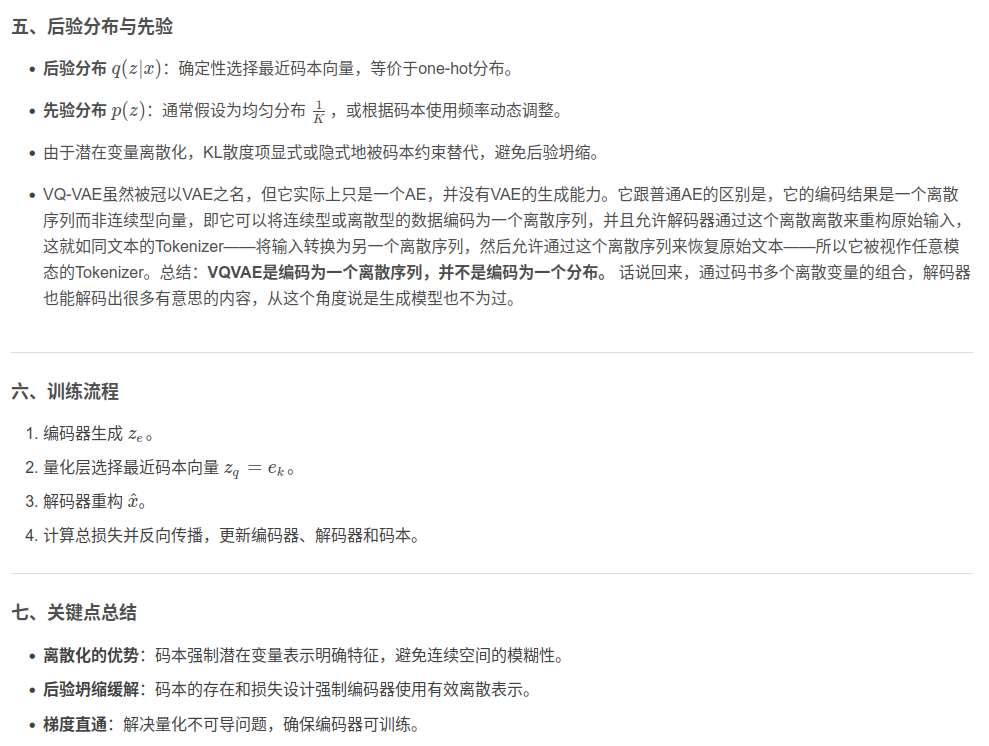

VQ-VAE 本身不能直接生成新数据，因为它没有学习索引的分布。要生成新样本，需要额外训练一个先验模型（如 PixelCNN、Transformer）来拟合离散索引的分布。